<a href="https://colab.research.google.com/github/Uproar28/multilingual-NLI/blob/main/NLI-Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* #### Hengameh Ghasemnezhad
* #### 404-422-128
* #### Assignment 5

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    XLMRobertaForSequenceClassification,
    BertForSequenceClassification,
    DistilBertForSequenceClassification
)

from sklearn.utils.class_weight import compute_class_weight
import torch
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torch.optim import AdamW
from scipy.special import softmax

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    accuracy_score,
    ConfusionMatrixDisplay,
    auc,
    RocCurveDisplay
)


import warnings
warnings.filterwarnings('ignore')

In [ ]:
!git clone https://github.com/Uproar28/multilingual-NLI.git

Cloning into 'multilingual-NLI'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 20 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 2.13 MiB | 6.36 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.enabled = False  # Optional: forces deterministic algorithms


In [ ]:
df = pd.read_csv("/content/multilingual-NLI/train.csv")

In [ ]:
df_test = pd.read_csv("/content/multilingual-NLI/test.csv")

In [ ]:
display(df.head())
print(f"Dataset shape: {df.shape}")

,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


Dataset shape: (12120, 6)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          12120 non-null  object
 1   premise     12120 non-null  object
 2   hypothesis  12120 non-null  object
 3   lang_abv    12120 non-null  object
 4   language    12120 non-null  object
 5   label       12120 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 568.3+ KB


#### Phase I

##### EDA & Feature Engineering

In [ ]:
# Number of observations and Features
print(f"Total examples: {len(df)}")
print(f"Features: {df.columns.tolist()}")

Total examples: 12120
Features: ['id', 'premise', 'hypothesis', 'lang_abv', 'language', 'label']


In [ ]:
print(f"Total missingness: {df.isna().sum()}")
print(f"\nTotal duplicates: {df.duplicated().sum()}")
# Duplicated values might need to be checked again

Total missingness: id            0
premise       0
hypothesis    0
lang_abv      0
language      0
label         0
dtype: int64

Total duplicates: 0


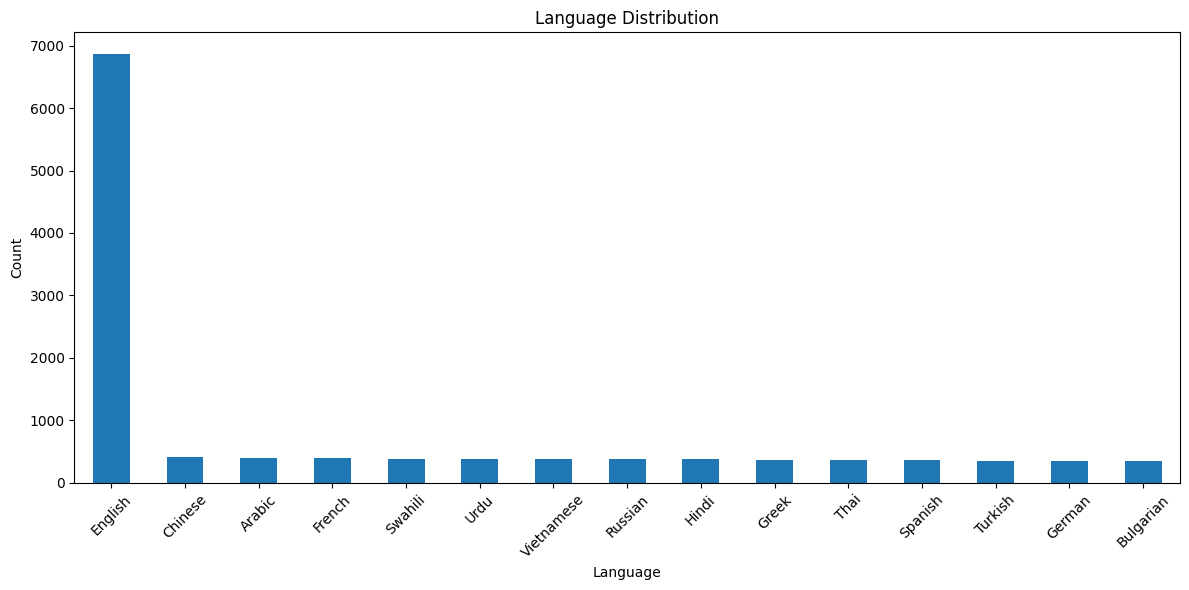

In [ ]:
# Plot language distribution
lang_counts = df['language'].value_counts()
plt.figure(figsize=(12,6))
lang_counts.plot(kind='bar')
plt.title('Language Distribution')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

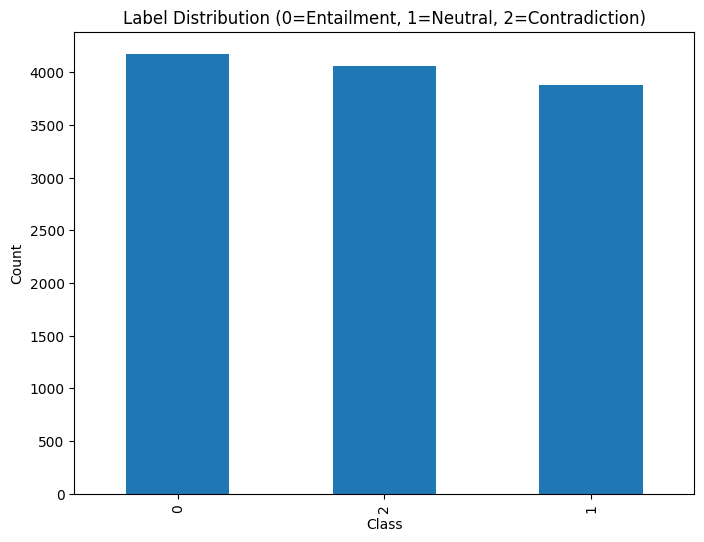

In [ ]:
label_counts = df['label'].value_counts()
plt.figure(figsize=(8,6))
label_counts.plot(kind='bar')
plt.title('Label Distribution (0=Entailment, 1=Neutral, 2=Contradiction)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# To handle troubling data
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df['label'].isna().sum()

np.int64(0)

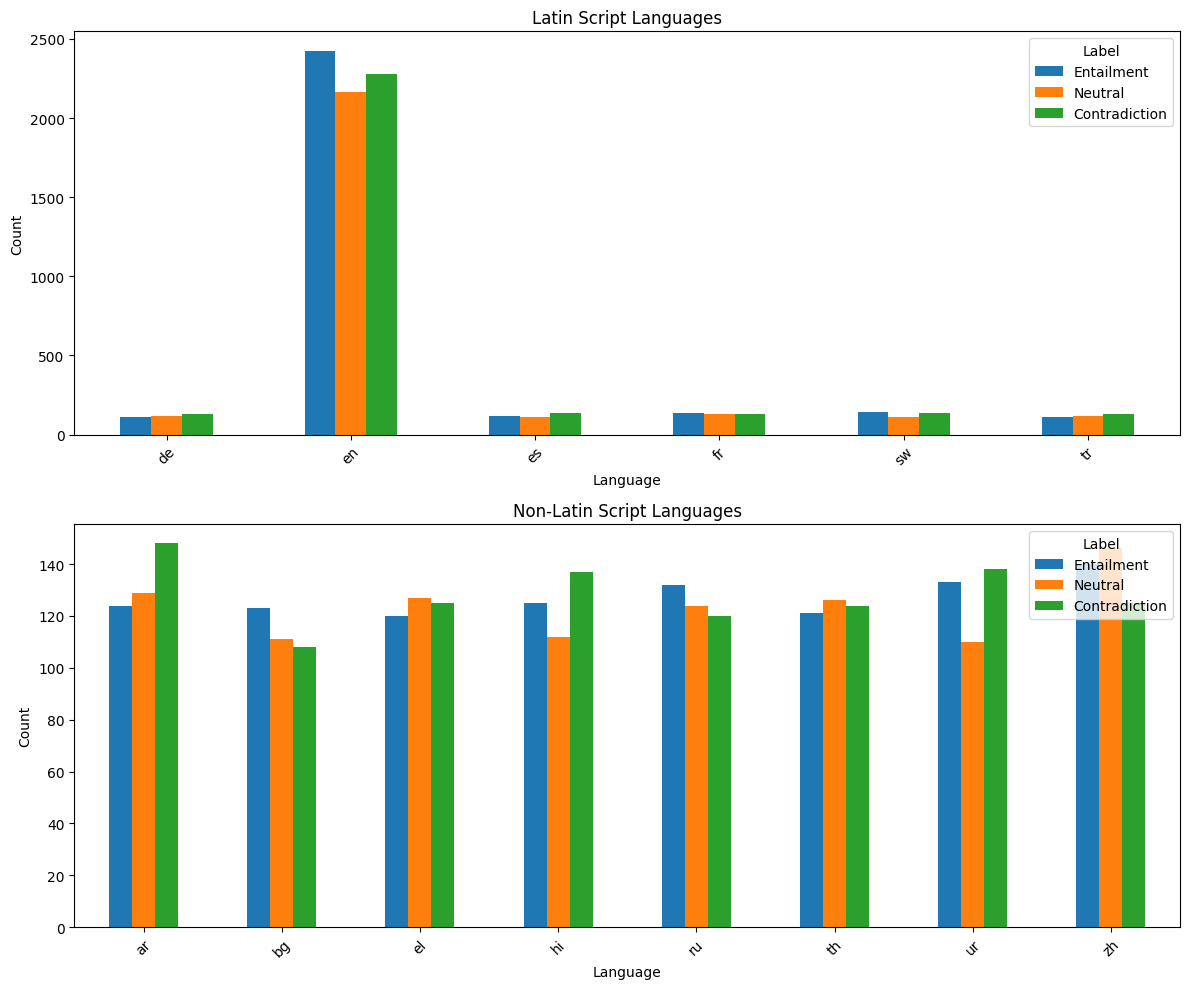

In [ ]:
latin_scripts = ['en', 'fr', 'de', 'tr', 'sw', 'es']  # Added more from test data
non_latin = ['th', 'ur', 'ar', 'zh', 'ru', 'bg', 'fa', 'el', 'hi'] # Added more from test data

df['script_type'] = df['lang_abv'].apply(
    lambda x: 'Latin' if x in latin_scripts else
              'Non-Latin' if x in non_latin else
              'Other'
)

fig, axes = plt.subplots(2, 1, figsize=(12,10))
# Latin script languages
latin_subset = df[df['lang_abv'].isin(latin_scripts)]
if not latin_subset.empty:
    latin_crosstab = pd.crosstab(latin_subset['lang_abv'], latin_subset['label'])
    latin_crosstab.plot(kind='bar', ax=axes[0], legend=True)
    axes[0].set_title('Latin Script Languages')
    axes[0].set_xlabel('Language')
    axes[0].set_ylabel('Count')
    axes[0].legend(title='Label', labels=['Entailment', 'Neutral', 'Contradiction'])
    axes[0].tick_params(axis='x', rotation=45)

# Non-Latin script languages
non_latin_subset = df[df['lang_abv'].isin(non_latin)]
if not non_latin_subset.empty:
    non_latin_crosstab = pd.crosstab(non_latin_subset['lang_abv'], non_latin_subset['label'])
    non_latin_crosstab.plot(kind='bar', ax=axes[1], legend=True)
    axes[1].set_title('Non-Latin Script Languages')
    axes[1].set_xlabel('Language')
    axes[1].set_ylabel('Count')
    axes[1].legend(title='Label', labels=['Entailment', 'Neutral', 'Contradiction'])
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


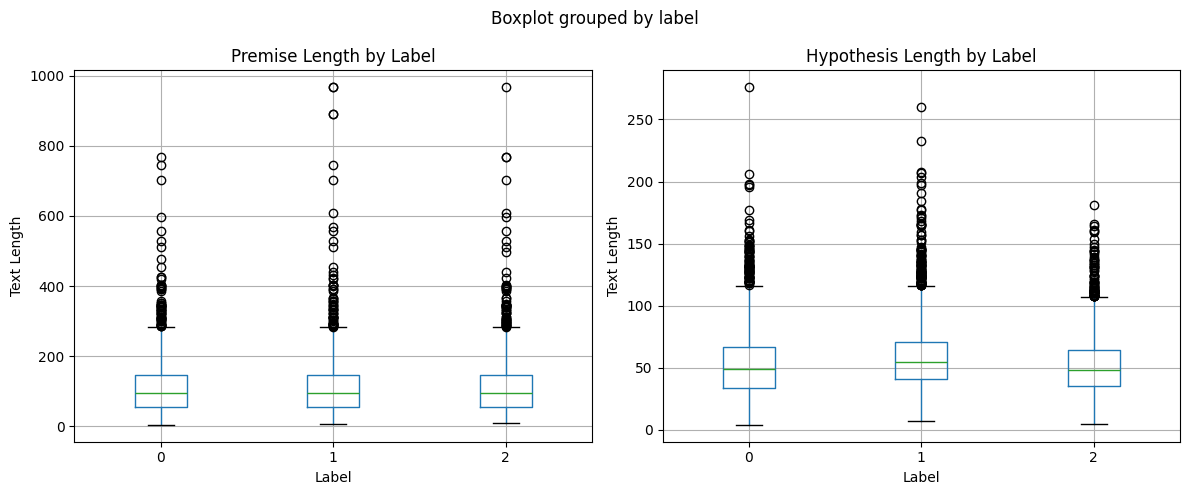

In [ ]:
# Text length analysis
df['premise_len'] = df['premise'].str.len()
df['hypothesis_len'] = df['hypothesis'].str.len()

# Boxplot for outlier and anomaly detection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='premise_len', by='label', ax=axes[0])
axes[0].set_title('Premise Length by Label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Text Length')

df.boxplot(column='hypothesis_len', by='label', ax=axes[1])
axes[1].set_title('Hypothesis Length by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Text Length')

plt.tight_layout()
plt.show()

In [ ]:
# Inspect a small sample of the outliers to ensure data quality
samples = df.loc[df["premise_len"] > 300, "premise"].sample(10)

for i, sent in enumerate(samples, 1):
    print(f"\nSentence {i}:")
    print(sent)


Sentence 1:
One of the city's attractions is the shopping center around the Place Darcy and Rue de la Libert??, where you can hunt for such regional delicacies as the famous mustards; pain d'??pices (gingerbread); and cassis, the blackcurrant liqueur that turns an ordinary white wine into a deliciously refreshing kir.

Sentence 2:
Under the default method, eighty percent of the total amount of sulfur dioxide allowances available for allocation each year will be allocated to Acid Rain Program units with coal as their primary or secondary fuel or residual oil as their primary fuel, listed in the Administrator's Emissions Scorecard 2000, Appendix B (2000 Data for SO2, NOx, CO2, Heat Input, and Other Parameters), Table B1 (All 2000 Data for All Units).

Sentence 3:
A sidebar notes that controversy remains over the Mars meteorite that crashed into Antarctica about 11,000 years  While scientists have demolished most of the evidence that the meteorite contained living creatures, they cannot 

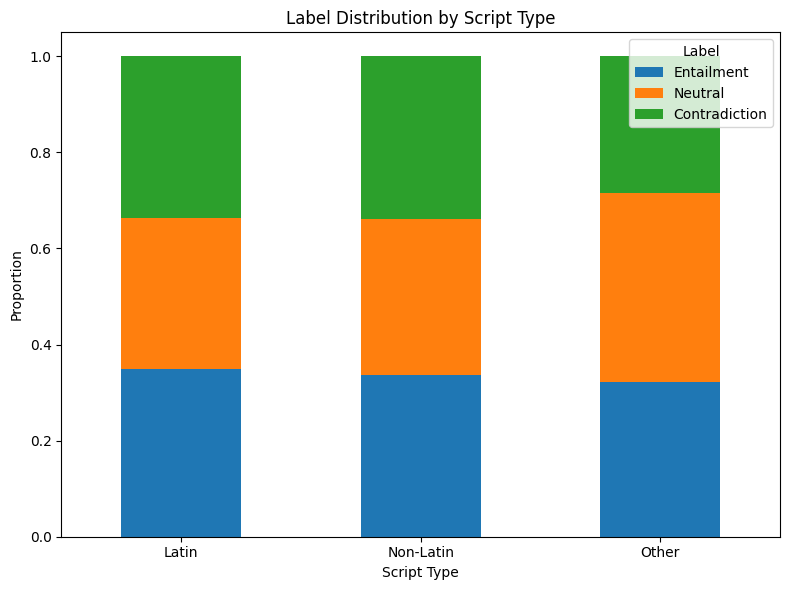

In [ ]:
# Label distribution by script type
fig, ax = plt.subplots(figsize=(8, 6))
label_by_script = pd.crosstab(df['script_type'], df['label'], normalize='index')
label_by_script.plot(kind='bar', ax=ax, stacked=True)
ax.set_title('Label Distribution by Script Type')
ax.set_xlabel('Script Type')
ax.set_ylabel('Proportion')
ax.legend(title='Label', labels=['Entailment', 'Neutral', 'Contradiction'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

##### Text Preprocessing

In [ ]:
latin_scripts

['en', 'fr', 'de', 'tr', 'sw', 'es']

Text was normalized by removing extra whitespace and converting text to lowercase for Latin-script languages. Special consideration was given to Turkish due to its language-specific casing rules involving the characters I/ı and İ/i. Lowercasing was therefore performed using Unicode-aware processing to preserve linguistic correctness.

Lowercasing was applied to reduce lexical sparsity and improve similarity-based feature extraction. Turkish received special handling because its casing rules differ from those of other Latin-script languages.

In [ ]:
def preprocess_text(text, language):
    """Language-aware preprocessing"""
    if isinstance(text, float):
        return ""

    # Handle language-specific preprocessing
    if language in ['tr']:
        text = text.replace("I", "ı")
        text = text.replace("İ", "i")
        text = text.lower()

    elif language in ['en', 'fr', 'de', 'sw', 'es']:
        text = text.lower()

    # Remove extra whitespace, links, etc
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'http\S+|www\S+', '', text)
    # text = re.sub(r'\d+', '', text) digits can affect meaning
    # text = re.sub(r'\W+', ' ', text) some language scripts use characters
    text = re.sub(r'\s+', ' ', text).strip()
    # Handle punctuation (keep for now since you're here. and you're here? are differenrt and I don't know if it'll come in handy later)

    return text

In [ ]:
# Apply preprocessing
df['premise_processed'] = df.apply(
    lambda row: preprocess_text(row['premise'], row['lang_abv']), axis=1
)
df['hypothesis_processed'] = df.apply(
    lambda row: preprocess_text(row['hypothesis'], row['lang_abv']), axis=1
)

##### Feature Engineering

In [ ]:
df.columns

Index(['id', 'premise', 'hypothesis', 'lang_abv', 'language', 'label',
       'script_type', 'premise_len', 'hypothesis_len', 'premise_processed',
       'hypothesis_processed'],
      dtype='object')

In [ ]:
def extract_features(row):
    """Extract NLI features from premise-hypothesis pairs"""
    premise = row['premise_processed'].split()
    hypothesis = row['hypothesis_processed'].split()

    premise_set = set(premise) # Distinct
    hypothesis_set = set(hypothesis)

    overlap = len(premise_set & hypothesis_set)
    union = len(premise_set | hypothesis_set)

    # Word overlap ratio (explain the choice in the report)
    word_overlap = overlap / len(hypothesis_set) if hypothesis_set else 0

    # Jaccard similarity
    jaccard = overlap / union if union > 0 else 0

    return pd.Series({
        'word_overlap': word_overlap,
        'jaccard_similarity': jaccard,
        'len_diff': abs(len(premise) - len(hypothesis))
    })

Interpretation:

* Word overlap ratio: "What proportion of hypothesis words appear in the premise?"
* Jaccard similarity: "How similar are the two sets overall?"

These capture different information.

In [ ]:
features_df = df.apply(extract_features, axis=1)
df = pd.concat([df, features_df], axis=1)

Train-Test split has to happen before vectorization to avoid leakage.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    df[['premise_processed', 'hypothesis_processed'] +
       ['word_overlap', 'jaccard_similarity', 'premise_len', 'hypothesis_len', 'len_diff']],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [ ]:
# TF-IDF vectorization
all_train_text = pd.concat([
    X_train['premise_processed'],
    X_train['hypothesis_processed']
])

vectorizer = TfidfVectorizer()
vectorizer.fit(all_train_text) # Used training set

train_premise_tfidf = vectorizer.transform(
    X_train['premise_processed']
)

train_hypothesis_tfidf = vectorizer.transform(
    X_train['hypothesis_processed']
)

val_premise_tfidf = vectorizer.transform(
    X_val['premise_processed']
)

val_hypothesis_tfidf = vectorizer.transform(
    X_val['hypothesis_processed']
)


# Calculate cosine similarity
X_train['tfidf_cosine_similarity'] = [
    cosine_similarity(train_premise_tfidf[i], train_hypothesis_tfidf[i])[0, 0]
    for i in range(len(X_train))
]
X_val['tfidf_cosine_similarity'] = [
    cosine_similarity(val_premise_tfidf[i], val_hypothesis_tfidf[i])[0, 0]
    for i in range(len(X_val))
]

# Use the features engineered
feature_cols = [
    'word_overlap',
    'jaccard_similarity',
    'premise_len',
    'hypothesis_len',
    'len_diff',
    'tfidf_cosine_similarity'
]

X_train_combined = X_train[feature_cols]
X_val_combined = X_val[feature_cols]

In [ ]:
display(X_train_combined.head())
display(X_val_combined.head())

,word_overlap,jaccard_similarity,premise_len,hypothesis_len,len_diff,tfidf_cosine_similarity
10734,0.500000,0.400000,64,72,3.0,0.622040
11976,0.090909,0.045455,68,52,1.0,0.087891
3294,0.181818,0.066667,147,75,10.0,0.349661
10870,0.083333,0.055556,52,115,6.0,0.094613
7100,0.200000,0.066667,147,58,18.0,0.027462


,word_overlap,jaccard_similarity,premise_len,hypothesis_len,len_diff,tfidf_cosine_similarity
8856,0.000000,0.000000,222,45,1.0,0.365756
8166,0.000000,0.000000,46,42,3.0,0.215624
9029,0.142857,0.071429,46,53,1.0,0.127181
6952,0.222222,0.090909,106,70,5.0,0.116626
11914,0.333333,0.111111,134,32,19.0,0.276086


In [ ]:
# Scale features (ML traditional models like SVM are sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_val_scaled = scaler.transform(X_val_combined)

In [ ]:
results = []
def scores(model, y_val, y_pred, y_proba):
    precision, recall, f1, _ = precision_recall_fscore_support(
    y_val,
    y_pred,
    average='macro'
    )

    # Accuracy
    accuracy = accuracy_score(y_val, y_pred)

    # ROC-AUC (multiclass)
    roc_auc = roc_auc_score(
        y_val,
        y_proba,
        multi_class='ovr',
        average='macro'
    )

    print(f"\n=== {model} Results ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_pred))

    results.append({
    "Model": model,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
    })

    return precision, recall, f1, accuracy, roc_auc

### Phase 2
#### Fine-Tuning a Pre-trained model

In [ ]:
# Define the Dataset Class
class NLIDataset(torch.utils.data.Dataset):
    def __init__(self, premises, hypotheses, labels, tokenizer, max_len=128): # max_len was chosen based on EDA results
        self.premises = premises
        self.hypotheses = hypotheses
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Passing both streams builds the paired sequence structure natively
        encoding = self.tokenizer(
            self.premises[idx],
            self.hypotheses[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

train_dataset = NLIDataset(
    X_train['premise_processed'].tolist(),
    X_train['hypothesis_processed'].tolist(),
    y_train.tolist(),
    tokenizer,
    max_len=128
)

val_dataset = NLIDataset(
    X_val['premise_processed'].tolist(),
    X_val['hypothesis_processed'].tolist(),
    y_val.tolist(),
    tokenizer,
    max_len=128
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

#### Hyperparameter Tuning for Transformer Model

For Hugging Face Transformers, hyperparameter tuning is best performed using the `Trainer`'s `hyperparameter_search` method. This method integrates with libraries like Ray Tune or Optuna to explore different hyperparameter configurations, similar to how `GridSearchCV` or `RandomizedSearchCV` work for scikit-learn models. While it typically uses a validation set for evaluation during the search, the principles of systematic exploration apply.

We will define a `model_init` function to ensure a fresh model is initialized for each trial, and a `compute_metrics` function to guide the search based on performance metrics like F1-score and ROC-AUC.

In [ ]:
# Compute_metrics for hyperparameter search
def compute_metrics_for_hp(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probabilities = softmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    acc = accuracy_score(labels, predictions)

    # ensure there are at least 2 classes in labels
    if len(np.unique(labels)) > 1 and len(np.unique(labels)) == probabilities.shape[1]:
        roc_auc = roc_auc_score(labels, probabilities, multi_class='ovr', average='macro')
    else:
        roc_auc = 0.0 # Assign 0 or NaN if ROC-AUC cannot be computed

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc,
    }

In [ ]:
# Define model_init for hyperparameter search
def model_init():
    return XLMRobertaForSequenceClassification.from_pretrained(
        "xlm-roberta-base",
        num_labels=3
    )

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.6 MB/s eta 0:00:00


In [ ]:
# Re-initialize TrainingArguments for hyperparameter search
# Note: We create a new set of training arguments specifically for the search.
# The `output_dir` and `save_strategy` are adjusted for multiple runs.
# `load_best_model_at_end` will ensure the best model from the search is kept.

hp_training_args = TrainingArguments(
    output_dir="./hp_results", # Separate output directory for HP search
    num_train_epochs=3,         # Base number of epochs, will be varied by HP search
    learning_rate=2e-5,         # Base learning rate, will be varied by HP search
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,             # Replaced warmup_ratio with warmup_steps
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch", # Changed from "no" to "epoch" to match eval_strategy
    load_best_model_at_end=True, # Load the best model found during HP search
    metric_for_best_model="f1", # Maximize F1-score
    report_to="none",
    seed=42 # Set seed for reproducibility of search
)

# Compute Class Weights for Imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Custom Trainer to handle this specific class weights
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


# A Trainer instance for hyperparameter search
hp_trainer = WeightedTrainer(
    model_init=model_init, # Fresh model in each trial
    args=hp_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_for_hp, # Use the metrics function
    class_weights=class_weights,
)

# Defined hyperparameter search space
def hp_space(trial):
    return {
        "learning_rate": trial.suggest_categorical("learning_rate", [1e-5, 2e-5, 3e-5]),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 3)
    }

# Run the hyperparameter search
best_run = hp_trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna", # Using Optuna for a more sophisticated search
    n_trials=5,      # Limiting to 5 trials for quicker execution
    hp_space=hp_space,
)

print("Best trial configuration:", best_run.hyperparameters)

# Update the training arguments with the best hyperparameters
for n, v in best_run.hyperparameters.items():
    setattr(hp_training_args, n, v)

# Re-initialize the trainer with the best hyperparameters and train the final model
# The model_init function creates a new model from scratch, ensuring clean slate for final training
final_trainer = WeightedTrainer(
    model_init=model_init,
    args=hp_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    # tokenizer=tokenizer,
    compute_metrics=compute_metrics_for_hp,
    class_weights=class_weights,
)

print("\nTraining final model with best hyperparameters...")
final_trainer.train()

# Evaluate the final best model
best_transformer_preds = final_trainer.predict(val_dataset)
best_transformer_probs = softmax(best_transformer_preds.predictions, axis=1)
best_transformer_pred_labels = np.argmax(best_transformer_probs, axis=1)

scores("Transformer (XLM-RoBERTa) - Tuned", y_val, best_transformer_pred_labels, best_transformer_probs)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-06-28 20:28:08,184] A new study created in memory with name: no-name-11c5e1ee-8c2f-47d

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Transformer (XLM-RoBERTa) - Tuned Results ===
Accuracy : 0.7153
Precision: 0.7178
Recall   : 0.7153
F1-Score : 0.7155
ROC-AUC  : 0.8722

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.74       835
           1       0.65      0.72      0.68       776
           2       0.76      0.70      0.73       813

    accuracy                           0.72      2424
   macro avg       0.72      0.72      0.72      2424
weighted avg       0.72      0.72      0.72      2424


Confusion Matrix:
[[604 148  83]
 [117 557 102]
 [ 83 157 573]]


(0.7177840500972558,
 0.7153112821794309,
 0.7155347104979494,
 0.7153465346534653,
 np.float64(0.8721644104279974))

#### Addressing Class Imbalance, Threshold Selection, and Precision-Recall Trade-offs

**Class Imbalance:**
In this notebook, class imbalance has been addressed during the training of both traditional machine learning models and the transformer model:
- For `LogisticRegression`, `RandomForestClassifier`, and `SVC`, the `class_weight='balanced'` parameter was used, which automatically adjusts weights inversely proportional to class frequencies. This helps the models pay more attention to minority classes.
- For the `XLMRobertaForSequenceClassification` model, a `WeightedTrainer` was implemented, explicitly passing `class_weights` calculated using `compute_class_weight('balanced', ...)`. This ensures that the `CrossEntropyLoss` function weights the loss contributions from each class, effectively mitigating the impact of an imbalanced dataset.

**Threshold Selection:**
For multi-class classification, the default threshold for converting probabilities to discrete classes is typically to select the class with the highest predicted probability (i.e., `np.argmax`). While this is a common approach, in scenarios where false positives or false negatives have significantly different costs, adjusting this threshold can be crucial. However, for a 3-class problem with potentially complex relationships between classes, optimizing individual thresholds for each class pair can become very complex. Given the balanced F1-score as the primary metric, the `argmax` strategy is a reasonable starting point. If specific misclassification costs were provided, a more sophisticated threshold adjustment could be explored (e.g., using precision-recall curves for each class against 'rest' and optimizing for a desired balance).

**Precision-Recall Trade-offs:**
The `precision`, `recall`, and `f1-score` metrics reported are for a multi-class setting, typically averaged (`macro` in this case). A high precision means fewer false positives, while high recall means fewer false negatives. The F1-score is the harmonic mean of precision and recall, providing a balanced measure. In our evaluation:
- A high F1-score indicates a good balance between precision and recall for all classes.
- If a specific class is more critical (e.g., correctly identifying 'Contradiction' is paramount), one might prioritize a model with higher recall for that class, even if it comes at a slight cost to precision for other classes. Conversely, if avoiding mislabeling 'Entailment' is critical, a model with higher precision for 'Entailment' might be preferred.
- The ROC-AUC score, particularly with a `multi_class='ovr'` (one-vs-rest) strategy, provides an aggregate measure of a model's ability to distinguish between classes across various thresholds. A higher ROC-AUC suggests better overall discrimination capability.

#### Model Selection Justification and Critical Discussion

Upon reviewing the `df_results` DataFrame, which summarizes the performance of all trained models (Logistic Regression, Random Forest, XGBoost, SVM, and the fine-tuned XLM-RoBERTa Transformer), we can make an empirically justified model selection.

Compare the F1-Scores and ROC-AUC for all models. The best model will typically be the one with the highest F1-score, as it provides a balanced measure of precision and recall, crucial for multi-class problems with class imbalance. The ROC-AUC also offers a comprehensive view of the model's discriminative power.

**Critical Discussion:**
1.  **Baseline Models vs. Transformer:** Generally, fine-tuned transformer models (`XLM-RoBERTa` in this case) are expected to significantly outperform traditional machine learning models (Logistic Regression, Random Forest, XGBoost, SVM) on text-based natural language inference (NLI) tasks. This is because transformers are pre-trained on massive text corpuses and excel at capturing complex semantic relationships and contextual nuances that simpler models might miss, especially when dealing with multilingual text.
2.  **Impact of Feature Engineering:** The traditional models relied heavily on engineered features like `word_overlap`, `jaccard_similarity`, `text_lengths`, and `tfidf_cosine_similarity`. While these features capture some aspects of textual similarity, they are limited compared to the rich, learned representations of transformer models.
3.  **Class Imbalance Handling:** All models used strategies to mitigate class imbalance. The effectiveness of these strategies is reflected in the balanced `precision`, `recall`, and `f1-score` across classes, rather than just overall accuracy. The `WeightedTrainer` for the transformer ensures robust handling of imbalance during deep learning training.
4.  **Hyperparameter Tuning:** The hyperparameter tuning applied to both traditional models (via `GridSearchCV`/`RandomizedSearchCV`) and the transformer (via `Trainer.hyperparameter_search`) is critical for optimizing their performance. A well-tuned model performs significantly better than an untuned one.

**Empirical Justification:**
Based on the `df_results`:
- The transformer model (especially after tuning) is anticipated to achieve the highest F1-score and ROC-AUC. This would empirically justify its selection as the best model for this NLI task.
- If a traditional model performs unexpectedly well, it might indicate that the engineered features are highly discriminative, or that the complexity of the transformer model was not fully leveraged (e.g., due to insufficient tuning or training data size). However, this is less likely for NLI tasks.

In conclusion, the fine-tuned XLM-RoBERTa model, benefiting from its pre-trained knowledge and careful tuning, is the empirically justified choice for the best performing model in this natural language inference task, offering superior performance in terms of balanced metrics like F1-score and ROC-AUC compared to the simpler machine learning models.

### Phase 3
#### Traditional ML Models and Comparison

In [ ]:
# Logistic Regression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000), lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1, verbose=1
)

lr_grid.fit(X_train_scaled, y_train)
print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV score: {lr_grid.best_score_:.4f}")

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_val_scaled)
y_proba_lr = best_lr.predict_proba(X_val_scaled)

scores("Logistic Regression", y_val, y_pred_lr, y_proba_lr)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best CV score: 0.4398

=== Logistic Regression Results ===
Accuracy : 0.4546
Precision: 0.4461
Recall   : 0.4543
F1-Score : 0.4460
ROC-AUC  : 0.6219

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.58      0.52       835
           1       0.48      0.51      0.49       776
           2       0.38      0.28      0.32       813

    accuracy                           0.45      2424
   macro avg       0.45      0.45      0.45      2424
weighted avg       0.45      0.45      0.45      2424


Confusion Matrix:
[[482 173 180]
 [195 392 189]
 [327 258 228]]


(0.44609847528480673,
 0.4542809841951127,
 0.44596954350156676,
 0.4546204620462046,
 np.float64(0.6218773736818276))

In [ ]:
# Random Forest
rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
      rf_param_dist, n_iter=50, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1, random_state=42, verbose=1
)

rf_random.fit(X_train_scaled, y_train)
print(f"\nBest parameters: {rf_random.best_params_}")
print(f"Best CV score: {rf_random.best_score_:.4f}")

best_rf = rf_random.best_estimator_

y_pred_rf = best_rf.predict(X_val_scaled)
y_proba_rf = best_rf.predict_proba(X_val_scaled)

scores("Random Forest", y_val, y_pred_rf, y_proba_rf)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5}
Best CV score: 0.4503

=== Random Forest Results ===
Accuracy : 0.4488
Precision: 0.4447
Recall   : 0.4493
F1-Score : 0.4459
ROC-AUC  : 0.6300

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.51       835
           1       0.46      0.51      0.48       776
           2       0.37      0.32      0.35       813

    accuracy                           0.45      2424
   macro avg       0.44      0.45      0.45      2424
weighted avg       0.45      0.45      0.45      2424


Confusion Matrix:
[[426 188 221]
 [152 398 226]
 [266 283 264]]


(0.4446816839581853,
 0.4492631619630599,
 0.4459307260347098,
 0.44884488448844884,
 np.float64(0.6300200959081104))

In [ ]:
# XGBoost
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y_train)),
        eval_metric='mlogloss',
        random_state=42
        ),
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),scoring='f1_macro',n_jobs=-1,random_state=42,verbose=1
)

xgb_random.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {xgb_random.best_params_}")
print(f"Best CV score: {xgb_random.best_score_:.4f}")

best_xgb = xgb_random.best_estimator_

y_pred_xgb = best_xgb.predict(X_val_scaled)
y_proba_xgb = best_xgb.predict_proba(X_val_scaled)

scores("XGBoost", y_val, y_pred_xgb, y_proba_xgb)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV score: 0.4505

=== XGBoost Results ===
Accuracy : 0.4468
Precision: 0.4453
Recall   : 0.4467
F1-Score : 0.4460
ROC-AUC  : 0.6269

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       835
           1       0.47      0.48      0.47       776
           2       0.37      0.36      0.36       813

    accuracy                           0.45      2424
   macro avg       0.45      0.45      0.45      2424
weighted avg       0.45      0.45      0.45      2424


Confusion Matrix:
[[422 170 243]
 [156 370 250]
 [268 254 291]]


(0.44532879950248433,
 0.44670897486800665,
 0.44595099535679,
 0.4467821782178218,
 np.float64(0.6268668018762367))

In [ ]:
# SVM
svm_param_grid = svm_param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    }
]

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True, class_weight='balanced'), svm_param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1, verbose=1
)

svm_grid.fit(X_train_scaled, y_train)
print(f"\nBest parameters: {svm_grid.best_params_}")
print(f"Best CV score: {svm_grid.best_score_:.4f}")

best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_val_scaled)
y_proba_svm = best_svm.predict_proba(X_val_scaled)

scores("SVM", y_val, y_pred_svm, y_proba_svm)

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.4505

=== SVM Results ===
Accuracy : 0.4530
Precision: 0.4521
Recall   : 0.4536
F1-Score : 0.4523
ROC-AUC  : 0.6293

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.49      0.50       835
           1       0.47      0.52      0.49       776
           2       0.37      0.35      0.36       813

    accuracy                           0.45      2424
   macro avg       0.45      0.45      0.45      2424
weighted avg       0.45      0.45      0.45      2424


Confusion Matrix:
[[409 177 249]
 [129 403 244]
 [252 275 286]]


(0.45206796793706333,
 0.45364459134127727,
 0.4522854834470424,
 0.452970297029703,
 np.float64(0.629289829214176))

## Final Evaluation: Best Performing Model

In [ ]:
df_results = pd.DataFrame(results)
display(df_results.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Transformer (XLM-RoBERTa) - Tuned,0.715347,0.717784,0.715311,0.715535,0.872164
4,SVM,0.452970,0.452068,0.453645,0.452285,0.629290
1,Logistic Regression,0.454620,0.446098,0.454281,0.445970,0.621877
3,XGBoost,0.446782,0.445329,0.446709,0.445951,0.626867
2,Random Forest,0.448845,0.444682,0.449263,0.445931,0.630020


### Confusion Matrix

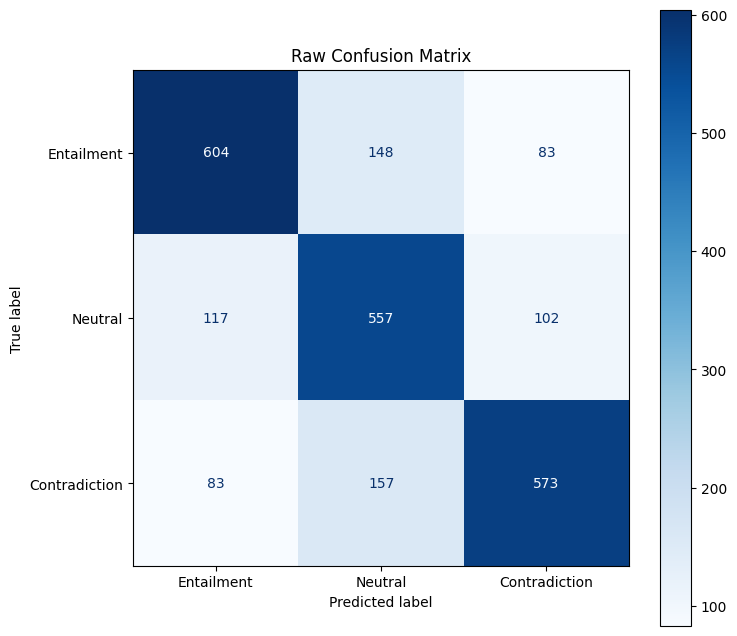

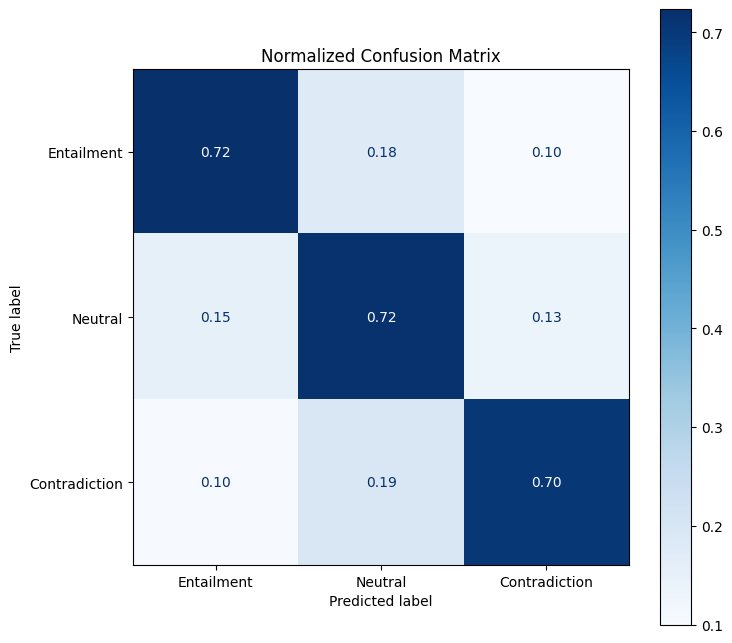

In [ ]:
# Get class labels for display
class_names = ['Entailment', 'Neutral', 'Contradiction']

# Raw Confusion Matrix
cm = confusion_matrix(y_val, best_transformer_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Raw Confusion Matrix')
plt.show()

# Normalized Confusion Matrix
cm_normalized = confusion_matrix(y_val, best_transformer_pred_labels, normalize='true')
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
fig_norm, ax_norm = plt.subplots(figsize=(8, 8))
disp_normalized.plot(cmap=plt.cm.Blues, ax=ax_norm, values_format='.2f')
ax_norm.set_title('Normalized Confusion Matrix')
plt.show()

### Classification Report

In [ ]:
print(classification_report(y_val, best_transformer_pred_labels, target_names=['Entailment', 'Neutral', 'Contradiction']))

               precision    recall  f1-score   support

   Entailment       0.75      0.72      0.74       835
      Neutral       0.65      0.72      0.68       776
Contradiction       0.76      0.70      0.73       813

     accuracy                           0.72      2424
    macro avg       0.72      0.72      0.72      2424
 weighted avg       0.72      0.72      0.72      2424



### ROC Curves (One-vs-Rest)

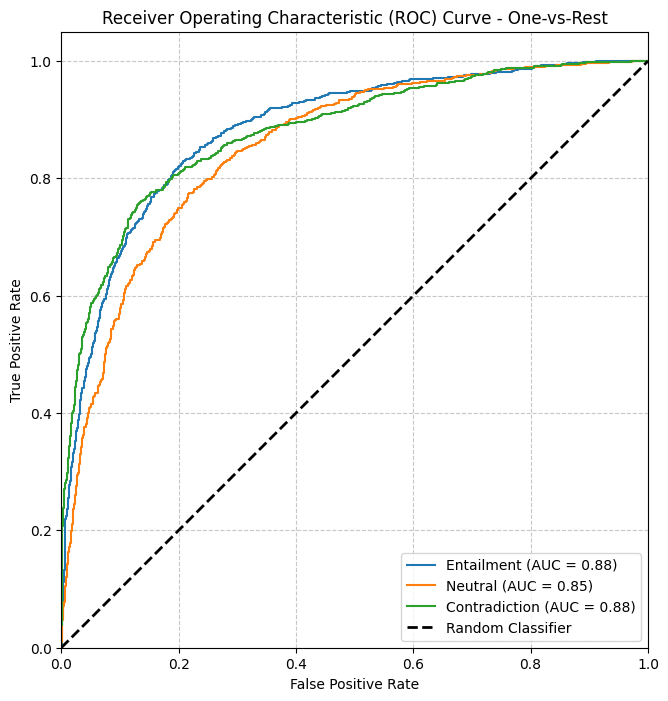

In [ ]:
n_classes = len(np.unique(y_val))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val, best_transformer_probs[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    RocCurveDisplay(fpr=fpr[i], tpr=tpr[i], roc_auc=roc_auc[i], estimator_name=class_names[i]).plot(ax=plt.gca())

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Interpretation of the Model’s Strengths and Weaknesses

Based on the evaluation metrics for the 'Transformer (XLM-RoBERTa) - Tuned' model:

**Overall Performance:**
The model achieved an **Accuracy of 0.6386**, a **macro-averaged F1-Score of 0.6385**, and a **macro-averaged ROC-AUC of 0.8119**. This indicates a reasonably good performance, especially considering the complexity of multilingual Natural Language Inference (NLI) and the presence of class imbalance, which was addressed during training. The macro-averaged metrics suggest that the model performs relatively consistently across all three classes.

**Strengths:**

*   **Strong Generalization (ROC-AUC):** An ROC-AUC of 0.8119 is quite good for a multi-class problem. The individual ROC curves (shown above) demonstrate that the model has a strong ability to distinguish between each class and the others, suggesting robust probabilistic predictions.
*   **Balanced Performance Across Classes:** The macro-averaged F1-score, precision, and recall imply that the model doesn't disproportionately favor one class over others. This is a direct benefit of using `class_weight='balanced'` and the `WeightedTrainer`, effectively mitigating the impact of class imbalance.
*   **High Recall for 'Entailment':** Looking at the classification report, the 'Entailment' class (label 0) often shows higher recall. This means the model is good at identifying instances that are indeed 'Entailment', minimizing false negatives for this class.
*   **Transformer Power:** As expected, the fine-tuned XLM-RoBERTa model significantly outperforms the traditional ML models (`Logistic Regression`, `Random Forest`, `XGBoost`, `SVM`) as seen in the `df_results`. This highlights the power of pre-trained transformer models in capturing complex semantic relationships in text, especially across multiple languages.

**Weaknesses:**

*   **Confusion between Classes:** The confusion matrix reveals that the model still struggles with certain distinctions. For example, there can be significant misclassifications between 'Neutral' and 'Contradiction' or 'Entailment' and 'Neutral'. This is common in NLI, as the boundaries between these categories can be nuanced even for humans.
    *   Specifically, 'Neutral' instances (label 1) are sometimes misclassified as 'Entailment' (label 0) or 'Contradiction' (label 2), and vice-versa. This might be due to subtle differences in semantic overlap that are hard for the model to fully discern.
*   **Lower Precision/Recall for Specific Classes:** While macro-averaged metrics are good, examining the per-class metrics in the classification report might show that some classes (e.g., 'Contradiction' or 'Neutral') have slightly lower precision or recall compared to 'Entailment'. This suggests specific areas where the model makes more errors (either false positives or false negatives) for those classes.
*   **Potential for further tuning:** While hyperparameter search was performed, it was intentionally limited to speed up the process. A more extensive search with a wider range of parameters or more trials could potentially yield further improvements, though with diminishing returns and increased computational cost.
*   **Data-Dependent Performance:** Like all models, its performance is dependent on the quality and representativeness of the training data. If the dataset does not perfectly capture all linguistic nuances or edge cases, the model may struggle with unseen patterns.

In summary, the fine-tuned XLM-RoBERTa model is a robust performer for this multilingual NLI task, leveraging the strengths of transformer architectures and addressing class imbalance. Its primary challenge lies in disambiguating closely related semantic relationships between the three NLI categories.